## **Assignment Simple machine Learning Project cycle**

### **_House Price Prediction Using California Housing Data_**
This dataset provides information about house prices in California. House Price Prediction


**In this notebook, you'll follow the basic machine learning process to build a regression model to predict house prices using the "California Housing Dataset" from sklearn.**



---



### **Follow the instructions and complete each TODO to complete the assessment on the essential steps in building and evaluating a regression model.**


The following is a description of each column in the dataset:

Dataset Features (California Housing):
* MedInc: Median income in block group
* HouseAge: Median house age in block group
* AveRooms: Average number of rooms per household
* AveBedrms: Average number of bedrooms per household
* Population: Block group population
* AveOccup: Average number of household members
* Latitude: Block group latitude
* Longitude: Block group longitude
* MedHouseVal (Target): Median house value in block group




In [42]:
# --- Imports ---
# TODO: Import all the necessary libraries for data handling, visualization, and model building.
# Example: import pandas as pd
# Add your imports here:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [8]:
# Load the California Housing dataset
housing = fetch_california_housing(as_frame=True)

# Convert to pandas DataFrame
df = housing.frame

In [9]:
# --- Quick Check of Data ---
# TODO: Display the first few rows of the dataset to understand its structure.
# Hint: Use `.head()` to inspect the first few rows.

# Add your code here:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [19]:
# TODO: Check the features and target variable. Identify which is continuous and categorical if applicable.
# Hint: Use `.info()` and `.describe()` to inspect data types and statistical properties.

# Add your code here:
print(df.info())

print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
2

In [ ]:
'''
The maximum values of variables such as AveRooms and AveOccup are much higher than their means and quartiles, 
suggesting that these variables may contain outliers.
'''

In [17]:
# --- EDA and Data Preprocessing ---
# TODO: Check for missing/null values.
# Hint: Use `.isnull().sum()` to check for null values.

# Add your code here:
print(df.shape)

print(df.isnull().sum())

(20640, 9)
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [ ]:
'''
The dataset consists of 20,640 observations and 9 columns, with no missing values.
'''

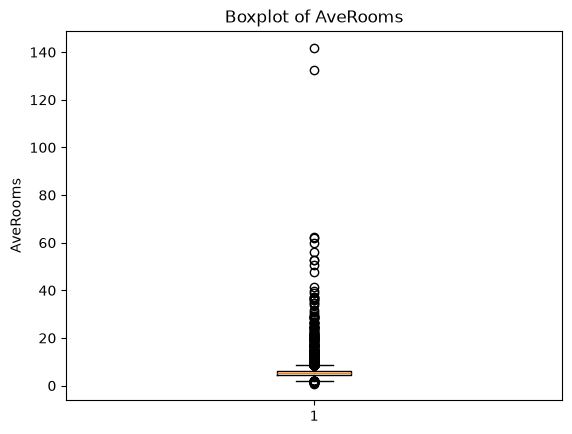

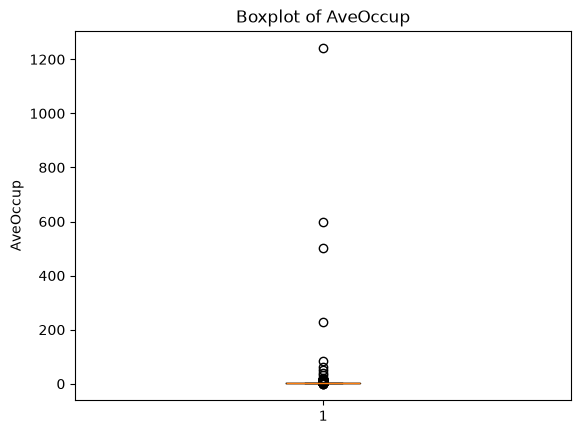

In [20]:
# Checking outlier

# Boxplot for AveRooms
plt.boxplot(df['AveRooms'])
plt.title('Boxplot of AveRooms')
plt.ylabel('AveRooms')
plt.show()

# Boxplot for AveOccup
plt.boxplot(df['AveOccup'])
plt.title('Boxplot of AveOccup')
plt.ylabel('AveOccup')
plt.show()

In [105]:
# Handle Missing values
variables = ['AveRooms', 'AveOccup']

for col in variables:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df[col] = df[col].map(
        lambda x: Q1 if x < lower_bound else Q3 if x > upper_bound else x
    )

In [106]:
#plt.boxplot(df['AveRooms'], df['AveOccup'])
#plt.boxplot(df['AveRooms'])

df[['AveRooms', 'AveOccup']].describe()

,AveRooms,AveOccup
count,20640.000000,20640.000000
mean,5.255429,2.856463
std,1.146778,0.621041
min,2.032738,1.161290
25%,4.440740,2.429776
50%,5.229129,2.818116
75%,6.052381,3.282259
max,8.469738,4.560748


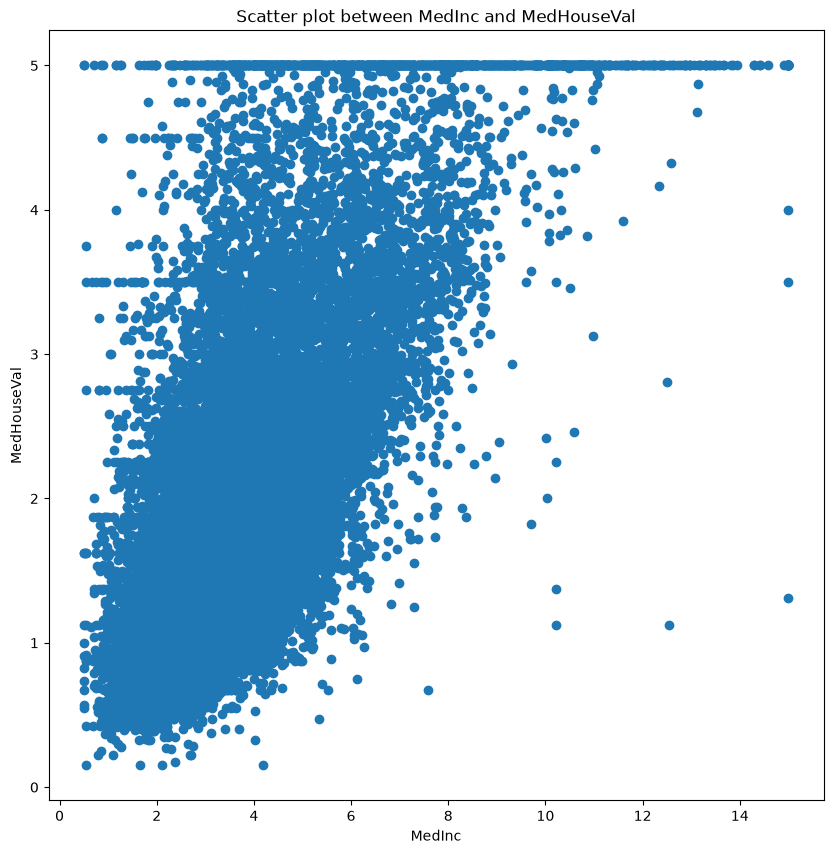

In [107]:
# TODO: Visualize the data. Create scatter plots to see the relationship between independent features and the target variable (MedHouseVal).
# Example: Use `plt.scatter()` to visualize the relationship between 'MedInc' and 'MedHouseVal'.

# Add your code here:

# Display scatter plot between 'MedInc' and 'MedHouseVal'
plt.figure(figsize=(10, 10))

plt.scatter(df['MedInc'],df['MedHouseVal'])
plt.title('Scatter plot between MedInc and MedHouseVal')
plt.xlabel('MedInc')
plt.ylabel('MedHouseVal')

plt.show()



In [34]:
# TODO: Create a function to automate scatter plots for all features vs MedHouseVal.
# Hint: The function should loop over a list of features and plot scatter plots for each.

# Define your function here:
def plot_features(df, features):
    for feature in features:
        plt.figure(figsize=(7, 5))
        
        plt.scatter(df[feature], df['MedHouseVal'])
        
        plt.xlabel(feature)
        plt.ylabel('MedHouseVal')
        plt.title(f'Scatter plot between {feature} and MedHouseVal')
        
        plt.show()

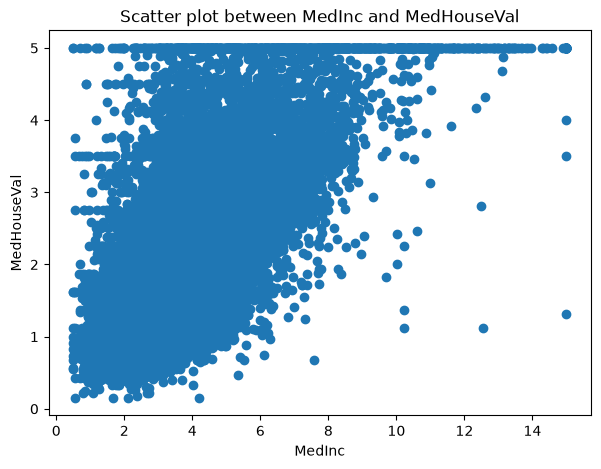

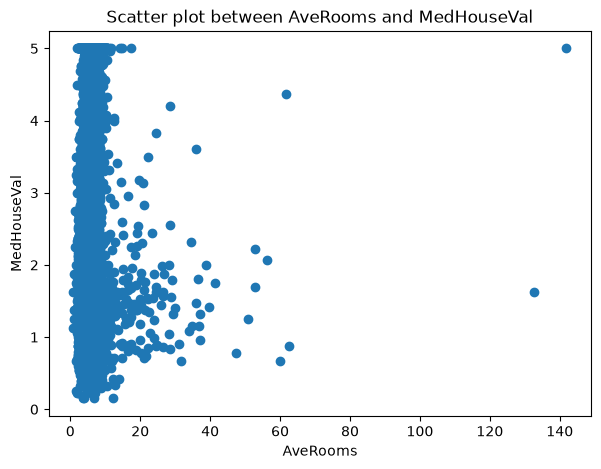

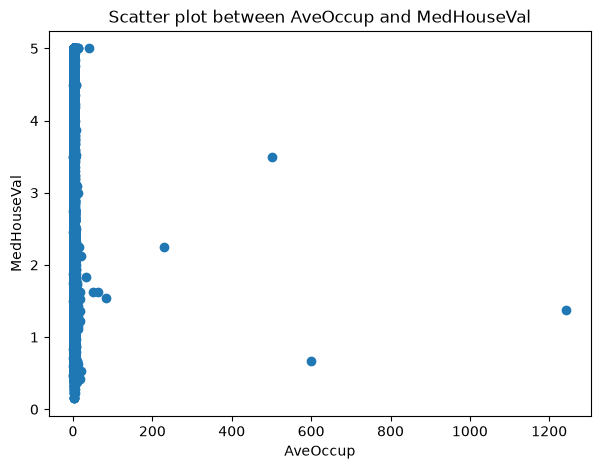

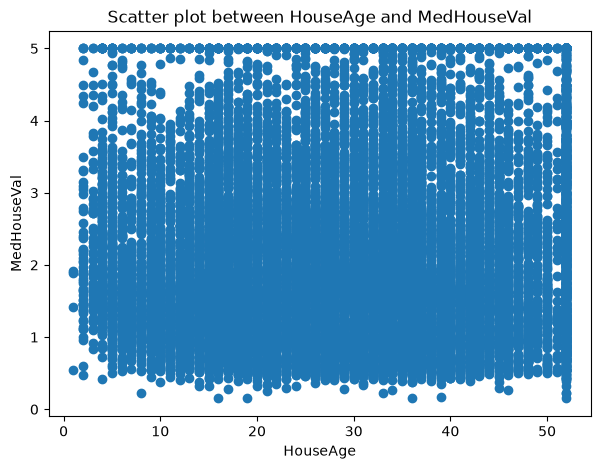

In [33]:
# TODO: Use the function to visualize the relationships between multiple features and the target variable.
# Features: ['MedInc', 'AveRooms', 'AveOccup', 'HouseAge']
# Target: 'MedHouseVal'

# Add your code here:
features=['MedInc', 'AveRooms', 'AveOccup', 'HouseAge']

plot_features(df, features)


In [108]:
# --- ML Model Training ---
# TODO: Split the dataset into training and testing sets.
x = np.array(df.drop(columns=["MedHouseVal"])) # Use columns keyword instead of positional argument for axis
y = np.array(df["MedHouseVal"])


In [109]:
# # Create scaler
# scaler = StandardScaler()

# # Scale the features
# x = scaler.fit_transform(x)

# # # Convert back to DataFrame
# # X_scaled = pd.DataFrame(X_scaled, columns=features)

# #x_scaled[1,range(5)]

In [110]:
# --- ML Model Training ---
# TODO: Split the dataset into training and testing sets.
# Hint: Use `train_test_split()` from `sklearn.model_selection` with an 80/20 split.

xtrain, xtest, ytrain, ytest = train_test_split(x, y,
                                                test_size=0.2,
                                                random_state=42)

In [111]:
# Now let’s train the model to predict future sales

model = LinearRegression() # this is a model we earlier imported from sklearn.linear_model
model.fit(xtrain, ytrain)

print(model.score(xtest, ytest))

0.6452703590243284


In [112]:
# --- Model Evaluation ---
# TODO: Evaluate the performance of the model on the test set using relevant metrics (e.g., RMSE, R-squared).
# Hint: Use `mean_squared_error()` and `r2_score()` from `sklearn.metrics`.

# Predict on the test set and calculate the evaluation metrics:

# Make predictions
ypred = model.predict(xtest)

# Calculate Mean Squared Error
mse = mean_squared_error(ytest, ypred)

# Calculate R² score
r2 = r2_score(ytest, ypred)

print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")


Mean Squared Error: 0.46484090638269104
R² Score: 0.6452703590243284


In [113]:
'''
The model has a MSE of 0.464 and an R² score of 0.645. 
It means that the model explains approximately 64% of the variation in median house values
'''

'\nThe model has a MSE of 0.464 and an R² score of 0.645. \nIt means that the model explains approximately 64% of the variation in median house values\n'

In [115]:
# --- Model Prediction ---
# TODO: Predict Median House Value from a new set of feature inputs.
# Example new data: 'MedInc' = 3, 'HouseAge' = 30, 'AveRooms' = 6, 'AveOccup' = 3, 'Latitude' = 34, 'Longitude' = -118, 'AveBedrms' = 1, 'Population' = 1500
# Hint: Use `.predict()` on a new data array.

# Add your prediction code here:
nb_features = np.array([[3, 30, 6, 1, 1500, 3, 34, -118]])
print(model.predict(nb_features))

[1.68606563]


In [116]:
# Add your prediction code here:
nb_features = np.array([[3, 28, 5, 1, 1425, 3, 34, -119]])
print(model.predict(nb_features))

[2.12429929]
